#Import Library

Library:
* `Pandas` :	membaca dan mengolah dataset
* `Numpy` :	operasi numerik
* `Train_test_split` : membagi data train dan test
* `StratifiedKFold`	: cross validation dengan distribusi kelas seimbang
* `Cross_val_score` :	evaluasi model dengan CV
* `StandardScaler`	: normalisasi data
* `SimpleImputer`	: mengisi missing value
* `Pipeline`	: menggabungkan preprocessing + model
* `ROC AUC`	: mengukur kemampuan model membedakan kelas
* `Precision` :	ketepatan prediksi kasus
* `Recall` :	evalusais untuk mendeteksi kasus
* `XGBClassifier`	: model gradient boosting
* `TensorFlow / Keras` :	membangun neural network
* `Joblib` :	menyimpan model

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, precision_score, recall_score

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Load Data

In [26]:
df = pd.read_csv("sepsis_emr_data.csv")
df.head()

,patient_id,heart_rate,respiratory_rate,temperature,wbc_count,lactate_level,age,num_comorbidities,sepsis_risk
0,PID0001,88,17,37.1,7.9,1.1,51,1,0
1,PID0002,115,25,38.6,16.0,3.6,78,3,1
2,PID0003,79,16,36.9,7.1,0.9,42,0,0
3,PID0004,96,20,37.5,10.2,1.6,65,2,0
4,PID0005,122,29,39.2,18.1,4.7,83,4,1


In [27]:
X = df.drop(columns=["patient_id","sepsis_risk"])
y = df["sepsis_risk"]

#Data Cleaning

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1753 entries, 0 to 1752
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1753 non-null   object 
 1   heart_rate         1753 non-null   int64  
 2   respiratory_rate   1753 non-null   int64  
 3   temperature        1753 non-null   float64
 4   wbc_count          1753 non-null   float64
 5   lactate_level      1612 non-null   float64
 6   age                1753 non-null   int64  
 7   num_comorbidities  1753 non-null   int64  
 8   sepsis_risk        1753 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 123.4+ KB


In [29]:
df.isna().sum()

,0
patient_id,0
heart_rate,0
respiratory_rate,0
temperature,0
wbc_count,0
lactate_level,141
age,0
num_comorbidities,0
sepsis_risk,0


* Missing value diganti dengan `median`. Karena data medis sering memiliki outlier sehingga median lebih stabil dibanding mean.

* `StandardScaler()` untuk menyamakan skala fitur model Neural Network.

In [30]:
X = df.drop(columns=["patient_id","sepsis_risk"])
y = df["sepsis_risk"]

In [31]:
numeric_features = X.columns

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Feature Engineering

In [32]:
df_corr = df.drop(columns=["patient_id"])

In [33]:
corr_matrix = df_corr.corr()

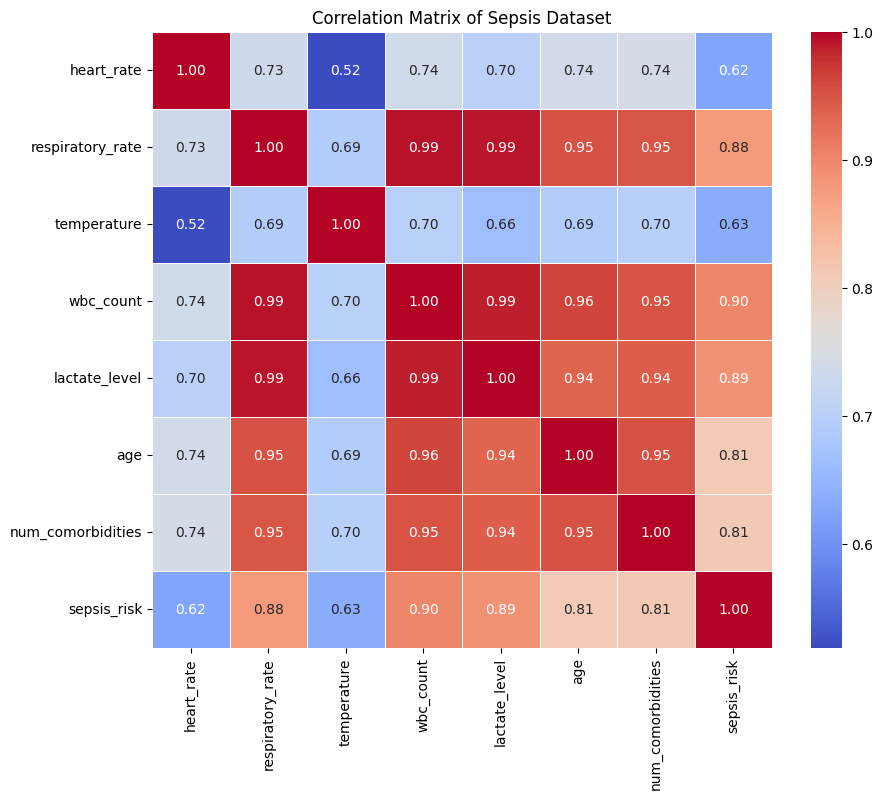

In [34]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Sepsis Dataset")
plt.show()

In [35]:
df['sepsis_risk'].value_counts(normalize=True) * 100

,proportion
sepsis_risk,
0,58.014832
1,41.985168


#Modelling

## Splitting Data

Data dibagi menjadi 2 bagian yaitu data training 80% dan data testing 20%. Mengapa skala pembagian tersebut jadi 80:20 ? Karena dengan pembagian dataset tersebut sangat umum dan melihat dari dataset yang tidak sedikit dan tidak terlalu banyak sehingga cocok untuk menggunakan rasio 80:20.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## XGBoost

In [37]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

In [38]:
pipeline_xgb.fit(X_train, y_train)

xgb_prob = pipeline_xgb.predict_proba(X_test)[:,1]

In [39]:
print(xgb_prob)
print

[0.00120288 0.99834013 0.00120288 0.99834013 0.00120288 0.00120288
 0.00120288 0.99834013 0.99834013 0.99834013 0.99834013 0.00120288
 0.00120288 0.00120288 0.99834013 0.00120288 0.00120288 0.99834013
 0.99834013 0.00120288 0.00120288 0.99834013 0.99834013 0.00120288
 0.99834013 0.00120288 0.99834013 0.00120288 0.00120288 0.99834013
 0.99834013 0.99834013 0.00120288 0.99834013 0.00120288 0.00120288
 0.00120288 0.00120288 0.00120288 0.00120288 0.00120288 0.99834013
 0.00120288 0.00120288 0.00120288 0.00120288 0.00120288 0.00120288
 0.99834013 0.00120288 0.00120288 0.99834013 0.00120288 0.99834013
 0.99834013 0.00120288 0.00120288 0.00120288 0.00120288 0.00120288
 0.99834013 0.00120288 0.99834013 0.99834013 0.00120288 0.99834013
 0.00120288 0.00120288 0.00120288 0.99834013 0.00120288 0.99834013
 0.00120288 0.00120288 0.99834013 0.99834013 0.00120288 0.99834013
 0.00120288 0.99834013 0.00120288 0.99834013 0.00120288 0.99834013
 0.99834013 0.00120288 0.00120288 0.99834013 0.99834013 0.0012

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

## Artificial Neural Network

In [40]:
def create_ann(input_dim):

    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["AUC"]
    )

    return model

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [42]:
ann_model = create_ann(X_train_processed.shape[1])

ann_model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - AUC: 0.2463 - loss: 0.7518 - val_AUC: 0.9795 - val_loss: 0.5052
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.9953 - loss: 0.4363 - val_AUC: 1.0000 - val_loss: 0.3002
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 1.0000 - loss: 0.2556 - val_AUC: 1.0000 - val_loss: 0.1742
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 1.0000 - loss: 0.1366 - val_AUC: 1.0000 - val_loss: 0.1074
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 1.0000 - loss: 0.0827 - val_AUC: 1.0000 - val_loss: 0.0737
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 1.0000 - loss: 0.0530 - val_AUC: 1.0000 - val_loss: 0.0543
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 1.0000 - loss: 0.0431 - val_AUC: 1.0000 - val_loss: 0.0426
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 1.0000 - loss: 0.0338 - val_AUC: 1.0000 - val_loss: 0.0350
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 1.0000 - loss: 0.0280 -

In [43]:
ann_prob = ann_model.predict(X_test_processed).flatten()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


## Ensemble Learning

In [44]:
final_prob = (0.6 * xgb_prob) + (0.4 * ann_prob)

final_pred = (final_prob > 0.5).astype(int)

## Evaluation

In [45]:
auc = roc_auc_score(y_test, final_prob)
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)

print("AUC:", auc)
print("Precision:", precision)
print("Recall:", recall)

AUC: 1.0
Precision: 1.0
Recall: 1.0


In [46]:
train_prob = pipeline_xgb.predict_proba(X_train)[:,1]
test_prob = pipeline_xgb.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_prob))
print("Test AUC:", roc_auc_score(y_test, test_prob))

Train AUC: 1.0
Test AUC: 1.0


In [47]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, final_pred))

[[204   0]
 [  0 147]]


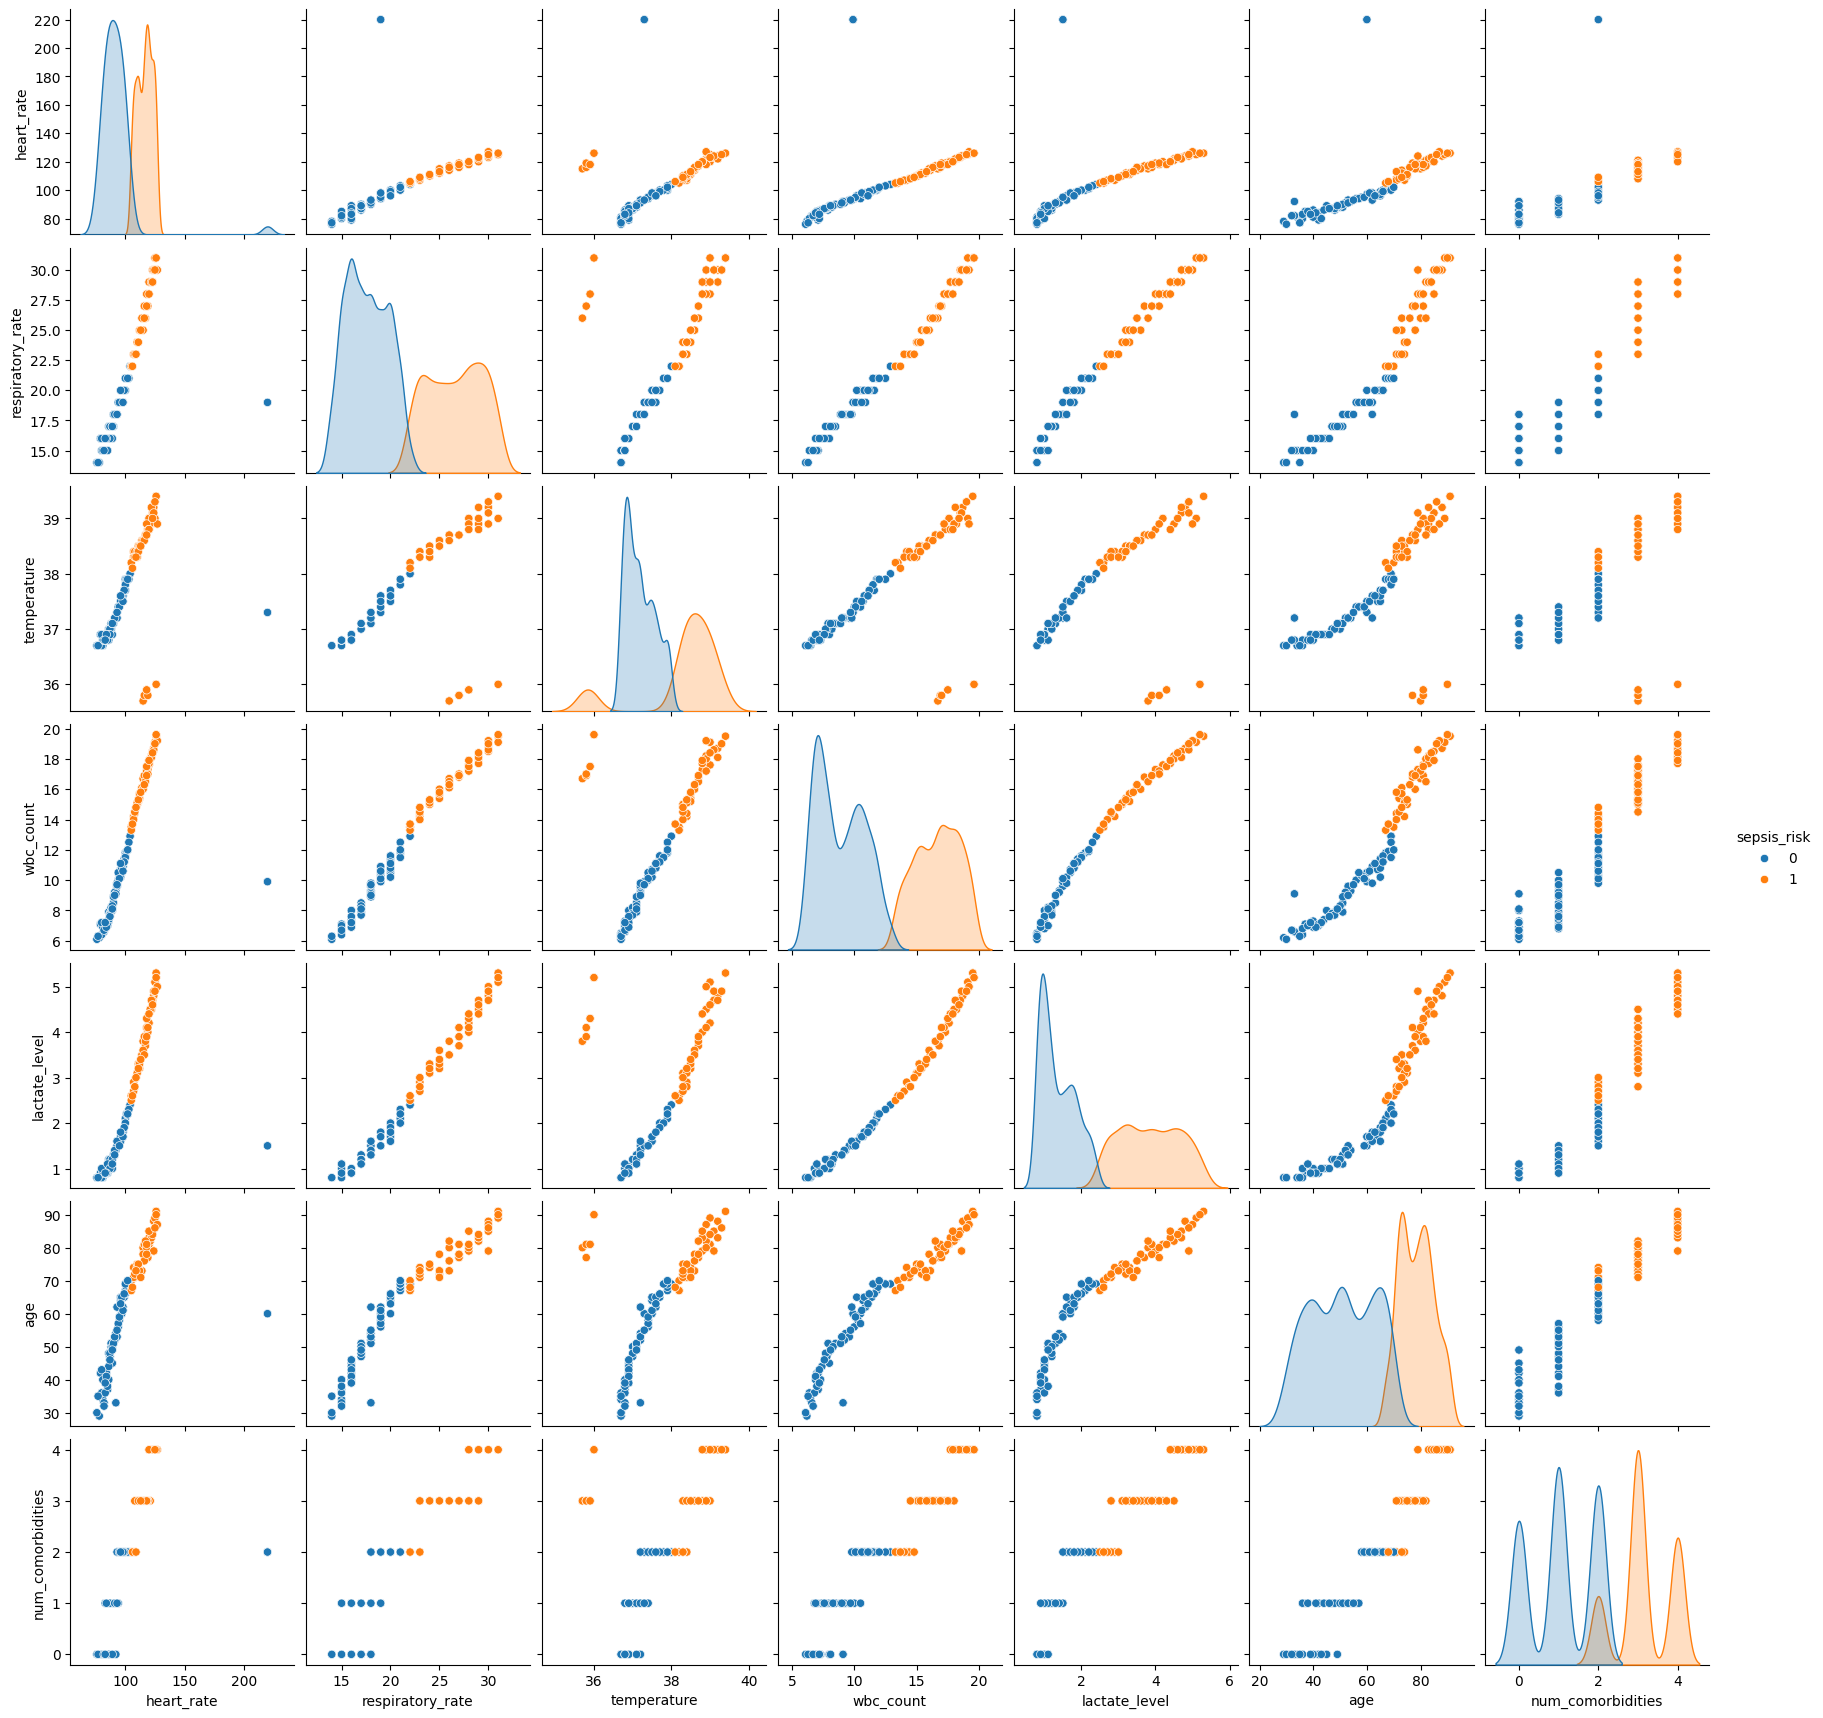

In [48]:
import seaborn as sns
sns.pairplot(df, hue="sepsis_risk")

Dilakukan uji cross validation karena melihat bahwa evaluasi AUC, Precision dan Recall adalah 100%. Fungsinya adalah untuk memastikan model generalizable dan menghindari overfitting.

In [49]:
kfold = StratifiedKFold(n_splits=5)

scores = cross_val_score(
    pipeline_xgb,
    X,
    y,
    cv=kfold,
    scoring="roc_auc"
)

print("CV AUC:", scores.mean())

CV AUC: 1.0


# Save Model

In [50]:
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(pipeline_xgb, "xgb_model.pkl")

ann_model.save("ann_model.h5")